In [ ]:
# ============================================================
# УСТАНОВКА TORCH-GEOMETRIC
# ============================================================

!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# БЛОК 1. Импорт библиотек
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn.functional as F
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_scipy_sparse_matrix

In [ ]:
# ============================================================
# БЛОК 2. Загрузка и предобработка данных
# ============================================================

FILE_PATH = "task4_1-genomic-ATGC-seq.txt"

def load_genomic_data(path):
    """
    Файл содержит строки вида:
    ID123  2  ACB  A A T C G G ...

    Первые 3 столбца:
    1) ID индивида
    2) Пол
    3) Популяция

    Остальные столбцы — последовательность ATGC.
    """
    rows = []

    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            parts = line.strip().split()

            if len(parts) < 4:
                continue

            sample_id = parts[0]
            sex = parts[1]
            population = parts[2]
            sequence = parts[3:]

            rows.append([sample_id, sex, population] + sequence)

    df = pd.DataFrame(rows)

    ids = df.iloc[:, 0].values
    sex = df.iloc[:, 1].astype(int).values
    labels = df.iloc[:, 2].values
    seq = df.iloc[:, 3:]

    return ids, sex, labels, seq


ids, sex, labels_raw, seq_df = load_genomic_data(FILE_PATH)

print("Количество образцов:", len(ids))
print("Количество генетических признаков:", seq_df.shape[1])
print("Классы:", np.unique(labels_raw))

Количество образцов: 995
Количество генетических признаков: 10101
Классы: ['ACB' 'ASW' 'ESN' 'GWD' 'LWK' 'MSL' 'YRI']


In [ ]:
# ============================================================
# БЛОК 3. Кодирование нуклеотидов A/T/G/C в числа
# ============================================================

# Простое числовое кодирование:
# A -> 0, T -> 1, G -> 2, C -> 3
# Если встречается неизвестный символ, ставим 0.
nucleotide_map = {
    "A": 0,
    "T": 1,
    "G": 2,
    "C": 3
}

X = seq_df.replace(nucleotide_map).fillna(0).astype(np.float32).values

# Добавим пол как дополнительный признак
sex = sex.reshape(-1, 1).astype(np.float32)
X = np.hstack([sex, X])

# Кодируем метки популяций в числа 0..6
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels_raw)

print("Форма X:", X.shape)
print("Форма y:", y.shape)
print("Кодировка классов:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

/tmp/ipykernel_10214/3336960142.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = seq_df.replace(nucleotide_map).fillna(0).astype(np.float32).values


Форма X: (995, 10102)
Форма y: (995,)
Кодировка классов:
0 -> ACB
1 -> ASW
2 -> ESN
3 -> GWD
4 -> LWK
5 -> MSL
6 -> YRI


In [ ]:
# ============================================================
# БЛОК 4. Train / Validation / Test split
# ============================================================

num_nodes = X.shape[0]
indices = np.arange(num_nodes)

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

print("Train:", train_mask.sum().item())
print("Validation:", val_mask.sum().item())
print("Test:", test_mask.sum().item())

Train: 696
Validation: 149
Test: 150


In [ ]:
# ============================================================
# БЛОК 5. Построение k-NN графа генетического сходства
# ============================================================

K = 10

# kneighbors_graph строит граф ближайших соседей.
# Узлы — индивиды.
# Рёбра — генетически похожие индивиды.
knn_graph = kneighbors_graph(
    X,
    n_neighbors=K,
    mode="connectivity",
    include_self=False
)

# Делаем граф неориентированным
knn_graph = knn_graph.maximum(knn_graph.T)

edge_index, edge_weight = from_scipy_sparse_matrix(knn_graph)

print("Количество узлов:", num_nodes)
print("Количество рёбер:", edge_index.shape[1])

Количество узлов: 995
Количество рёбер: 13622


In [ ]:
# ============================================================
# БЛОК 6. Создание объекта Data для torch-geometric
# ============================================================

data = Data(
    x=torch.tensor(X, dtype=torch.float32),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.long),
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

print(data)

Data(x=[995, 10102], edge_index=[2, 13622], y=[995], train_mask=[995], val_mask=[995], test_mask=[995])


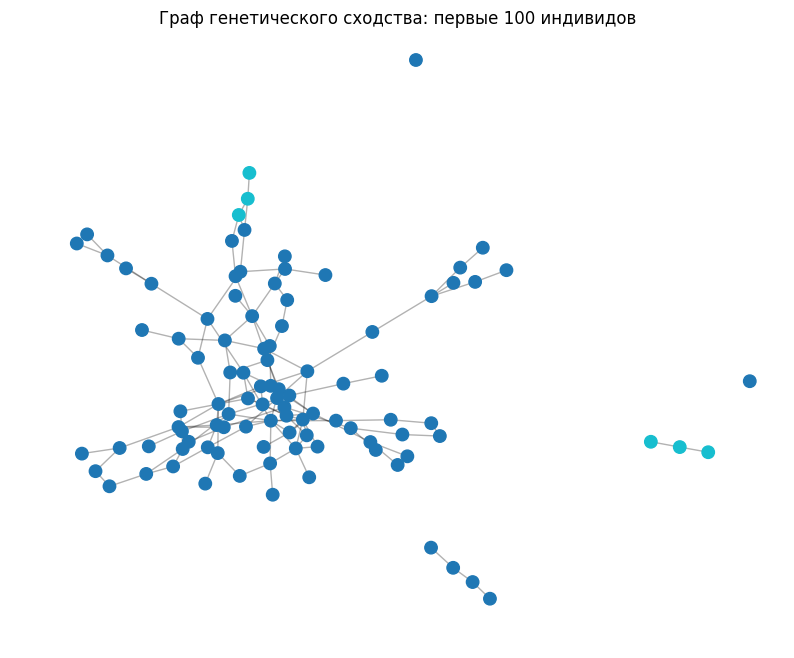

In [ ]:
# ============================================================
# БЛОК 7. Визуализация подграфа первых 100 узлов
# ============================================================

sub_nodes = 100

G = nx.from_scipy_sparse_array(knn_graph[:sub_nodes, :sub_nodes])

plt.figure(figsize=(10, 8))

colors = y[:sub_nodes]

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=colors,
    cmap=plt.cm.tab10,
    node_size=80
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.3
)

plt.title("Граф генетического сходства: первые 100 индивидов")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# БЛОК 8. Модель GCN
# ============================================================

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.4):
        super().__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.classifier(x)

        return x


input_dim = data.x.shape[1]
hidden_dim = 64
output_dim = len(label_encoder.classes_)

model = GCN(input_dim, hidden_dim, output_dim)

print(model)

GCN(
  (conv1): GCNConv(10102, 64)
  (conv2): GCNConv(64, 64)
  (classifier): Linear(in_features=64, out_features=7, bias=True)
)


In [ ]:
# ============================================================
# БЛОК 9. Обработка дисбаланса классов
# ============================================================

# Если классы представлены неравномерно, используем веса классов.
# Чем реже класс, тем больший вес он получает в функции потерь.

class_counts = np.bincount(y[train_idx])
class_weights = class_counts.sum() / (len(class_counts) * class_counts)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

print("Количество объектов по классам:", class_counts)
print("Веса классов:", class_weights)

Количество объектов по классам: [ 85  75 120 126  77  86 127]
Веса классов: tensor([1.1697, 1.3257, 0.8286, 0.7891, 1.2913, 1.1561, 0.7829])


In [ ]:
# ============================================================
# БЛОК 10. Функции обучения и оценки
# ============================================================

def train_one_epoch():
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(mask):
    model.eval()

    out = model(data.x, data.edge_index)
    preds = out.argmax(dim=1)

    y_true = data.y[mask].cpu().numpy()
    y_pred = preds[mask].cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    return acc, f1, y_true, y_pred

In [ ]:
# ============================================================
# БЛОК 11. Обучение с валидацией и ранней остановкой
# ============================================================

EPOCHS = 300
PATIENCE = 30

best_val_f1 = 0
best_state = None
patience_counter = 0

train_f1_history = []
val_f1_history = []

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch()

    train_acc, train_f1, _, _ = evaluate(data.train_mask)
    val_acc, val_f1, _, _ = evaluate(data.val_mask)

    train_f1_history.append(train_f1)
    val_f1_history.append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

    if patience_counter >= PATIENCE:
        print("Ранняя остановка на эпохе:", epoch)
        break

model.load_state_dict(best_state)

Epoch 010 | Loss: 1.9482 | Train F1: 0.0314 | Val F1: 0.0308
Epoch 020 | Loss: 1.9481 | Train F1: 0.0314 | Val F1: 0.0308
Epoch 030 | Loss: 1.9479 | Train F1: 0.0285 | Val F1: 0.0293
Epoch 040 | Loss: 1.9479 | Train F1: 0.0285 | Val F1: 0.0293
Ранняя остановка на эпохе: 46


<All keys matched successfully>

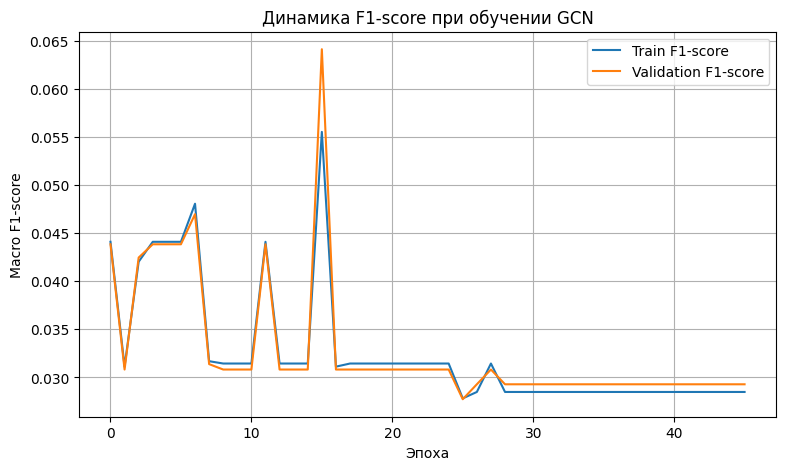

In [ ]:
# ============================================================
# БЛОК 12. График F1-score на обучении и валидации
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(train_f1_history, label="Train F1-score")
plt.plot(val_f1_history, label="Validation F1-score")
plt.xlabel("Эпоха")
plt.ylabel("Macro F1-score")
plt.title("Динамика F1-score при обучении GCN")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# БЛОК 13. Финальная оценка на тестовой выборке
# ============================================================

test_acc, test_f1, y_true, y_pred = evaluate(data.test_mask)

print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1-score:", round(test_f1, 4))

Test Accuracy: 0.1067
Test Macro F1-score: 0.0275


<Figure size 800x800 with 0 Axes>

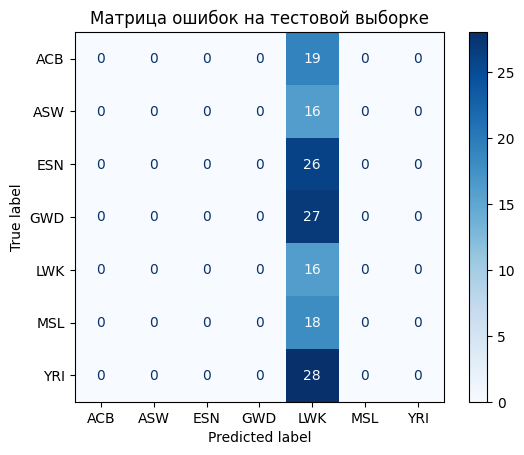

In [ ]:
# ============================================================
# БЛОК 14. Матрица ошибок
# ============================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Матрица ошибок на тестовой выборке")
plt.show()

In [ ]:
# ============================================================
# БЛОК 15. F1-score по каждому классу
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

         ACB       0.00      0.00      0.00        19
         ASW       0.00      0.00      0.00        16
         ESN       0.00      0.00      0.00        26
         GWD       0.00      0.00      0.00        27
         LWK       0.11      1.00      0.19        16
         MSL       0.00      0.00      0.00        18
         YRI       0.00      0.00      0.00        28

    accuracy                           0.11       150
   macro avg       0.02      0.14      0.03       150
weighted avg       0.01      0.11      0.02       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


В работе решалась задача классификации индивидов по 7 популяциям на основе генетических последовательностей. Данные были загружены из текстового файла, где каждая строка содержит идентификатор, пол, метку популяции и последовательность нуклеотидов A/T/G/C. Нуклеотиды были преобразованы в числовые признаки: A=0, T=1, G=2, C=3. Метки популяций были закодированы числами от 0 до 6.

Для учёта дисбаланса классов использовались веса классов в функции потерь CrossEntropyLoss. Редкие классы получают больший вес, поэтому ошибка на них сильнее влияет на обучение модели. Это помогает модели не игнорировать малочисленные популяции.

GCN подходит для этой задачи лучше, чем обычный MLP, потому что модель использует не только признаки отдельного индивида, но и связи между похожими индивидами. Для этого был построен k-NN граф генетического сходства: узлы — индивиды, рёбра — близость по генетическим признакам. GCN распространяет информацию по графу, поэтому признаки соседних похожих образцов помогают уточнять классификацию.

Хуже всего модель может классифицировать те популяции, которые генетически близки друг к другу или имеют мало обучающих примеров. В матрице ошибок это проявляется как частые перепутывания между отдельными классами. Возможная причина — пересечение генетических признаков между родственными популяциями и недостаточное количество уникальных мутационных паттернов для их разделения.